In [2]:
! cd /vol/bitbucket/lst20/long_POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/

In [ ]:
import utils.constants as constants
from tree.tree import ReadTree
from tree.node import RootNode, SemanticNode, SyntacticNode
from analysis.utils import Perplexity

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from collections import deque
import json
import re

def read_trees_to_df(strategy: str, gen_modelId: str, dataset: str, long=False) -> pd.DataFrame:
    '''
    read trees from perturb strategy and generator to pandas df
    columns:
    - question_id (from tree path)
    ----- all nodes -----
    - layer
    - id
    - type
    - prompt
    - rag_closest_match
    - rag_entities
    - answers
    - wiki_title
    --- root/sem node ---
    - root_similarity_score
    - complexity_score
    - fk_score
    - dc_score
    ----- syn node ------
    - syntax_similarity_score
    ---------------------
    '''
    def em_snippet(source: str, passage: str) -> list:
        snippets = []
        for match in re.finditer(re.escape(source.lower()), passage.lower()):
            start_idx = max(match.start() - 100, 0)
            end_idx = min(match.end() + 100, len(passage))
            snippet = passage[start_idx:end_idx]
            snippets.append(snippet)
            if len(snippets) == 4:
                break
        return snippets

    def extract_similarity(meta):
        if isinstance(meta, dict) and 'similarity' in meta:
            return meta['similarity']
        return 1
    long_prefix = "long_" if long else ""
    strategy_path = constants.STRATEGY_PATH_DICT[strategy]
    tree_dir_path = f"{constants.TREE_DIR}{long_prefix}{dataset}_treenodes/{strategy_path}/gemma3-12b_perturb/3_2_0/{gen_modelId.replace('/', '-')}/complete/"
    print(tree_dir_path)
    rows = []
    df = pd.read_parquet(constants.SHUFFLED_FILE)
    for _, row in df.iterrows():
        i = row['original_index']
        try:
            tree_path = f"{tree_dir_path}{i}_checked.pkl"
            tree = ReadTree.load_read_tree(tree_path)
            root = tree.root
            possible_answers = tree.possible_answers
            queue = deque([(root, 0)])  # (node, layer)
            visited = {root}
            question_id = i

            while queue:
                # evaluate answer
                node, layer = queue.popleft()
                base_found_match = False
                base_found_rag_match = False
                base_response = node.answers[gen_modelId]["base"].lower()
                base_rag_response = node.answers[gen_modelId]["base_rag"].lower()
                # TODO: fix dataset wrong format of possible answer column
                if isinstance(possible_answers, str):
                    try:
                        parsed = json.loads(possible_answers)
                        if not isinstance(parsed, list):
                            possible_answers = json.dumps([possible_answers])
                    except json.JSONDecodeError as e:
                        possible_answers = json.dumps([possible_answers])
                elif isinstance(possible_answers, list):
                    possible_answers = json.dumps(possible_answers)
                    
                for expected_answer in json.loads(possible_answers):
                    if base_response.__contains__(expected_answer.lower()):
                        base_found_match = True
                        break
                for expected_answer in json.loads(possible_answers):
                    if base_rag_response.__contains__(expected_answer.lower()):
                        base_found_rag_match = True
                        break
                    
                # find gen em source
                gen_em_source = None
                gen_em_snippet = None
                source = getattr(node, "rag_closest_match", None)
                if source:
                    doc_list = [match[0] for match in source] 
                    for doc in doc_list:
                        passage = doc["context"]
                        title = doc["title"]
                        format_resp = base_rag_response.lower()
                        format_resp = re.sub(r'^[^\w\d]+|[^\w\d]+$', '', format_resp, flags=re.UNICODE)
                        if format_resp in passage.lower():
                            gen_em_source = title
                            gen_em_snippet: list = em_snippet(format_resp, passage)
                            break  
                
                # find gt em source
                gt_em_source = None
                gt_em_snippet = []
                doc_list = [match[0] for match in tree.gt_passage] # Tuple[Dict[str, str], float]
                for doc in doc_list:
                    passage = doc["context"]
                    title = doc["title"]
                    for ans in possible_answers:
                        format_resp = ans.lower()
                        format_resp = re.sub(r'^[^\w\d]+|[^\w\d]+$', '', format_resp, flags=re.UNICODE)
                        if format_resp in passage.lower():
                            gt_em_source = title
                            for snippet in em_snippet(format_resp, passage):
                                gt_em_snippet.append(snippet)
                            break  
     
                node_data = {
                    "gen_modelId": gen_modelId,
                    "question_id": question_id,
                    "layer": layer,
                    "id": node.id,
                    "type": node.__class__.__name__,
                    "prompt": node.prompt,
                    "rag_closest_match": getattr(node, "rag_closest_match", None),
                    "rag_entities": getattr(node, "rag_entities", None),
                    "possible_answers": possible_answers,
                    "answers": node.answers,
                    "metadata": node.metadata,
                    "wiki_title": getattr(node, "wiki_title", None),
                    "base_found_rag_match": base_found_rag_match, 
                    "base_found_match": base_found_match,
                    "gen_em_source": gen_em_source,
                    "gen_em_snippet": gen_em_snippet,
                    "gt_em_source": gt_em_source,
                    "gt_em_snippet": list(set(gt_em_snippet)),
                }

                if isinstance(node, (RootNode, SemanticNode)):
                    node_data.update({
                        "root_similarity_score": getattr(node, "root_similarity_score", None),
                        "complexity_score": getattr(node, "complexity_score", None),
                        "fk_score": getattr(node, "fk_score", None),
                        "dc_score": getattr(node, "dc_score", None),
                    })

                elif isinstance(node, (SyntacticNode)):
                    node_data["syntax_similarity_score"] = getattr(node, "syntax_similarity_score", None)

                print()
                rows.append(node_data)

                for child in node.children:
                    if child not in visited:
                        queue.append((child, layer + 1))
                        visited.add(child)

        except FileNotFoundError:
            pass
        except RuntimeError as e:
            print(f"RuntimeError loading tree: {i}")
            
        except Exception as e:
            print(f"Error loading tree {i}: {e}")
    df = pd.DataFrame(rows)
    
    if df.get('metadata') is not None:
        df['similarity'] = df.get('metadata').apply(extract_similarity)
    else:
        df['similarity'] = 1
    # Convert nested dicts into a DataFrame
    base_rag_df = df['answers'].apply(lambda d: list(d.values())[0] if isinstance(d, dict) else {}).apply(pd.Series)

    # Merge back into the original DataFrame
    df = pd.concat([df, base_rag_df[['base', 'base_rag']]], axis=1)
    df = df.drop(columns=['answers'])

    return df
 
gen_models = ["google/gemma-3-12b-it", "google/gemma-3-1b-it", 'mistralai/Mistral-7B-Instruct-v0.2']
agg_funcs = {
    'base_found_rag_match': ['sum', lambda x: (~x).sum()],  # sum of Trues, sum of Falses
    'base_found_match': ['sum', lambda x: (~x).sum()],
    'fk_score': ['mean', 'var'],
    'dc_score': ['mean', 'var'],
    'root_similarity_score': ['mean', 'var'],
}
# Define base colors for models
model_colors = {
    'google/gemma-3-1b-it': 'green',
    'google/gemma-3-12b-it': 'blue',
    # 'mistral.mistral-7b-instruct-v0:2': 'red',
    'mistralai/Mistral-7B-Instruct-v0.2': 'red'
}


def plot_by_layer(df, gen_models, title, score_flag="em"):
    # Utility to lighten a color towards white
    def lighten_color(color, amount=0.5):
        try:
            c = mcolors.cnames[color]
        except KeyError:
            c = color
        c = mcolors.to_rgb(c)
        return tuple(x + (1.0 - x) * amount for x in c)
    
    fig, ax = plt.subplots(figsize=(10, 6))

    for model in gen_models:
        df_model = df[df['gen_modelId'] == model].copy()

        # Calculate percentages
        df_model['base_match_percentage'] = df_model["base_found_match_True_count"] / (
            df_model["base_found_match_True_count"] + df_model["base_found_match_False_count"]
        ) * 100
        df_model['base_rag_match_percentage'] = df_model["base_found_rag_match_True_count"] / (
            df_model["base_found_rag_match_True_count"] + df_model["base_found_rag_match_False_count"]
        ) * 100

        # Colors
        base_color = model_colors.get(model, 'black')
        rag_color = lighten_color(base_color, amount=0.5)

        # Plot base
        ax.plot(df_model['layer'], df_model['base_match_percentage'], 
                marker='o', color=base_color, label=f'{model.split("/")[-1]} - base')
        
        # Plot base_rag
        ax.plot(df_model['layer'], df_model['base_rag_match_percentage'], 
                marker='x', linestyle='--', color=rag_color, label=f'{model.split("/")[-1]} - base_rag')

    ax.set_ylabel('Correct Answer Percentage (%)')
    ax.set_xlabel('Layer')
    ax.set_title(f'{title} Correct Answer Percentage over Layers')
    ax.legend()
    ax.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

def get_perplexity(df):
    # Initialize perplexity metric
    metric = Perplexity()

    # Placeholder for scores
    perplexity_scores = []

    # Group by model and compute perplexity for each text
    for model_id, group in df.groupby("gen_modelId"):
        texts = group["prompt"].tolist()

        # Compute perplexities for this model
        results = metric._compute(
            predictions=texts,
            model_id=model_id,
        )

        # Assign per-example perplexities back to the group
        group_perplexities = results["perplexities"]

        # Append to list (preserve original index for merging)
        perplexity_scores.extend(zip(group.index, group_perplexities))

    # Create a new DataFrame from scores and merge back
    score_df = pd.DataFrame(perplexity_scores, columns=["index", "perplexity"])
    score_df.set_index("index", inplace=True)
    return score_df


/vol/bitbucket/lst20/long_POPQA_treenodes/prefix/gemma3-12b_perturb/3_2_0/google-gemma-3-12b-it/complete/
































































































































































































































































































































































































































































































































































































































































































































































































































































































































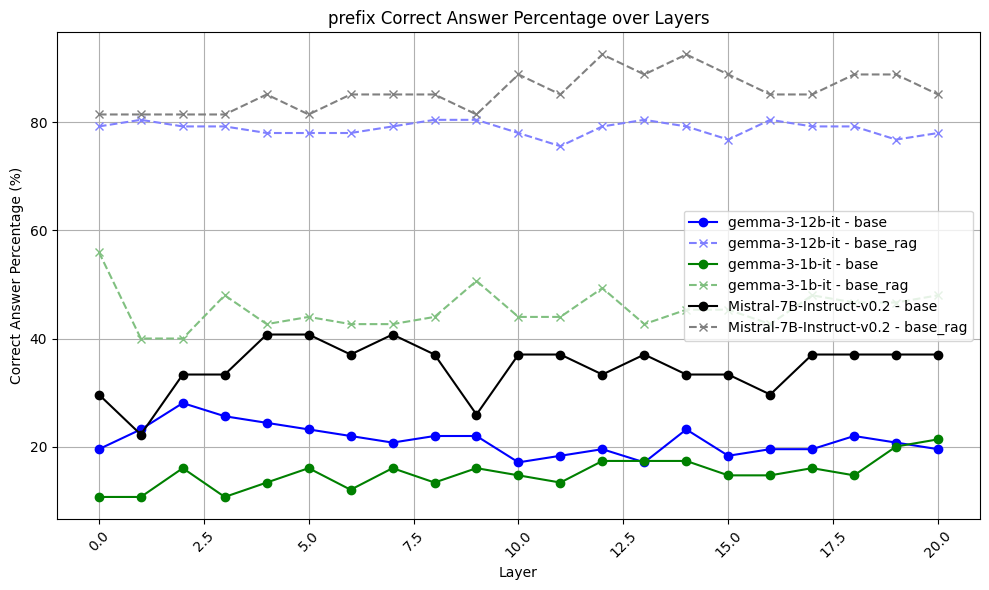

In [43]:
dfs_prefix_ = []

for model in gen_models:
    try:
        df = read_trees_to_df("prefix", model, "POPQA", long=True)
        print(f"tree count: {df["question_id"].nunique()}")
        print(f"{model} df len: {len(df)}")
        dfs_prefix_.append(df)
    except KeyError as e:
        pass

df_prefix_ = pd.concat(dfs_prefix_, ignore_index=True)
# df_prefix_ = get_perplexity(df_prefix_)
# df_prefix_.to_csv("analysis/df_prefix_.csv")

# perform groupby and aggregation
df_grouped_prefix_ = df_prefix_.groupby(['layer', 'gen_modelId']).agg(agg_funcs)

df_grouped_prefix_.columns = [
    'base_found_rag_match_True_count', 
    'base_found_rag_match_False_count',
    'base_found_match_True_count', 
    'base_found_match_False_count',
    'fk_score_mean', 
    'fk_score_var',
    'dc_score_mean', 
    'dc_score_var',
    'root_similarity_score_mean', 
    'root_similarity_score_var'
]
df_grouped_prefix_ = df_grouped_prefix_.reset_index()


plot_by_layer(df_grouped_prefix_, gen_models, title="prefix")